# NeuroQWERTY - tests AUC, XGBoost et représentations séquentielles

Ce notebook teste des représentations plus proches de l’état de l’art récent : features temporelles classiques, features fréquentielles, ondelettes discrètes et modèles `HistGB`, `SVC` et `XGBoost`.

L’objectif n’est pas encore de déclarer un modèle final, mais de voir si une représentation plus riche que les statistiques agrégées améliore la généralisation sujet-indépendante.

## Pourquoi ajouter AUC en plus du F1 ?

Le F1 dépend d’un seuil de décision. Si le seuil change, le F1 peut changer fortement. C’est utile quand on sait déjà comment transformer un score en classe `contrôle` ou `Parkinson`.

L’AUC ROC mesure plutôt si les sujets Parkinson reçoivent en moyenne un score plus élevé que les contrôles, sans fixer de seuil. C’est pour cela qu’elle est très utilisée en biomédical : dans une étude exploratoire, on veut souvent évaluer la qualité du score de risque avant de choisir le seuil clinique.

On ajoute aussi la PR-AUC, qui est plus sensible à la classe positive et devient utile quand les classes sont déséquilibrées. Ici le dataset est assez équilibré, donc ROC-AUC et F1 restent tous les deux informatifs.

In [1]:
from pathlib import Path
import re
import time
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pywt
from xgboost import XGBClassifier

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
OUTER_SPLITS = 5
INNER_SPLITS = 5
WINDOW = 300
STRIDE = 150
MIN_LEN = 300
WAVELET = "db4"
WAVELET_LEVEL = 4

ROOT = Path.cwd()
if not (ROOT / "data" / "neuroqwerty-mit-csxpd-dataset-1.0.0").exists() and ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA_ROOT = ROOT / "data" / "neuroqwerty-mit-csxpd-dataset-1.0.0"
print("ROOT", ROOT)


ROOT /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Hackaton/parkinson-detection


## 1. Chargement et nettoyage NeuroQWERTY

In [2]:
KEY_COLUMNS = ["key", "hold_time", "release_time", "press_time"]
MOUSE_RE = re.compile(r'"?mouse.+"?', re.I)
LONG_META_RE = re.compile(r'"?(Shift.+|Alt.+|Control.+)"?', re.I)
BACKSPACE_RE = re.compile(r'"?BackSpace"?', re.I)
PUNCT_OR_SPACE_RE = re.compile(r'"?(space|comma|period|semicolon|slash|minus|equal|apostrophe|Return)"?', re.I)
LEFT_KEYS = set("qwertasdfgzxcvb")
RIGHT_KEYS = set("yuiophjklnm")


def load_raw(path):
    df = pd.read_csv(path, header=None, names=KEY_COLUMNS)
    df["key"] = df["key"].astype(str).str.strip().str.replace('"', "", regex=False)
    for column in ["hold_time", "release_time", "press_time"]:
        df[column] = pd.to_numeric(df[column], errors="coerce")
    return df


def clean(df):
    d = df.dropna(subset=["hold_time", "release_time", "press_time"]).copy()
    key = d["key"].astype(str)
    keep = ~key.str.match(MOUSE_RE) & ~key.str.match(LONG_META_RE) & ~key.str.match(BACKSPACE_RE)
    d = d.loc[keep]
    d = d[(d.press_time > 0) & (d.release_time > 0) & (d.hold_time.between(0, 5))]
    d = d.sort_values("press_time").reset_index(drop=True)
    d["flight_time"] = d.press_time.diff()
    d.loc[d.flight_time < 0, "flight_time"] = np.nan
    d["is_space_punct"] = d.key.str.match(PUNCT_OR_SPACE_RE).astype(int)
    d["hand_left"] = d.key.str.lower().str[:1].isin(LEFT_KEYS).astype(int)
    d["hand_right"] = d.key.str.lower().str[:1].isin(RIGHT_KEYS).astype(int)
    d["hand_switch"] = (d.hand_left.diff().abs().fillna(0) > 0).astype(int)
    return d


def load_sessions():
    rows = []
    raws = {}
    for dataset in ["MIT-CS1PD", "MIT-CS2PD"]:
        gt = pd.read_csv(DATA_ROOT / dataset / f"GT_DataPD_{dataset}.csv")
        raw_dir = DATA_ROOT / dataset / f"data_{dataset}"
        for _, subject in gt.iterrows():
            for file_col in [column for column in gt.columns if column.startswith("file_")]:
                filename = subject.get(file_col)
                if pd.isna(filename) or not str(filename).strip():
                    continue
                session_uid = f"{dataset}_{int(subject.pID)}_{file_col}"
                raw_path = raw_dir / str(filename)
                cleaned = clean(load_raw(raw_path))
                raws[session_uid] = cleaned
                rows.append({
                    "session_uid": session_uid,
                    "dataset": dataset,
                    "pID": int(subject.pID),
                    "session_file": str(filename),
                    "session_id": file_col,
                    "label": int(bool(subject["gt"])),
                    "n_keys": len(cleaned),
                })
    return pd.DataFrame(rows), raws


sessions, raw_sessions = load_sessions()
print("sessions", len(sessions), "subjects", sessions.pID.nunique())
display(sessions.groupby("label").agg(sessions=("label", "size"), subjects=("pID", "nunique")))


sessions 116 subjects 85


,sessions,subjects
label,,
0,56,43
1,60,42


## 2. Features agrégées, fréquentielles et ondelettes

In [3]:
def safe_div(a, b):
    return np.nan if b is None or pd.isna(b) or abs(b) < 1e-12 else a / b


def entropy_binary(p):
    if pd.isna(p) or p <= 0 or p >= 1:
        return 0.0
    return -(p * np.log2(p) + (1 - p) * np.log2(1 - p))


def clean_signal(values, target_len=WINDOW):
    arr = pd.Series(values, dtype="float64").replace([np.inf, -np.inf], np.nan)
    median = arr.median()
    if pd.isna(median):
        median = 0.0
    arr = arr.fillna(median).to_numpy(dtype=float)
    if len(arr) < target_len:
        arr = np.pad(arr, (0, target_len - len(arr)), mode="edge")
    return arr[:target_len]


def stats_features(values, prefix):
    x = clean_signal(values)
    diff = np.diff(x)
    out = {
        f"{prefix}_mean": float(np.mean(x)),
        f"{prefix}_std": float(np.std(x)),
        f"{prefix}_median": float(np.median(x)),
        f"{prefix}_iqr": float(np.quantile(x, 0.75) - np.quantile(x, 0.25)),
        f"{prefix}_q10": float(np.quantile(x, 0.10)),
        f"{prefix}_q90": float(np.quantile(x, 0.90)),
        f"{prefix}_cv": safe_div(float(np.std(x)), float(np.mean(x))),
        f"{prefix}_diff_mean": float(np.mean(diff)),
        f"{prefix}_diff_std": float(np.std(diff)),
        f"{prefix}_diff_abs_mean": float(np.mean(np.abs(diff))),
    }
    for lag in [1, 2, 5, 10]:
        if len(x) > lag and np.std(x[:-lag]) > 0 and np.std(x[lag:]) > 0:
            out[f"{prefix}_autocorr_lag{lag}"] = float(np.corrcoef(x[:-lag], x[lag:])[0, 1])
        else:
            out[f"{prefix}_autocorr_lag{lag}"] = 0.0
    return out


def fft_features(values, prefix):
    x = clean_signal(values)
    x = x - np.mean(x)
    spectrum = np.abs(np.fft.rfft(x)) ** 2
    total = float(np.sum(spectrum)) + 1e-12
    thirds = np.array_split(spectrum, 3)
    return {
        f"{prefix}_fft_energy_total": total,
        f"{prefix}_fft_energy_low_ratio": float(np.sum(thirds[0]) / total),
        f"{prefix}_fft_energy_mid_ratio": float(np.sum(thirds[1]) / total),
        f"{prefix}_fft_energy_high_ratio": float(np.sum(thirds[2]) / total),
        f"{prefix}_fft_peak_bin": float(np.argmax(spectrum)),
    }


def wavelet_features(values, prefix):
    x = clean_signal(values)
    x = x - np.mean(x)
    coeffs = pywt.wavedec(x, WAVELET, level=WAVELET_LEVEL)
    out = {}
    for idx, coeff in enumerate(coeffs):
        name = "approx" if idx == 0 else f"detail_{idx}"
        abs_coeff = np.abs(coeff)
        energy = float(np.sum(coeff ** 2))
        prob = abs_coeff / (float(np.sum(abs_coeff)) + 1e-12)
        entropy = float(-np.sum(prob * np.log2(prob + 1e-12)))
        out.update({
            f"{prefix}_dwt_{name}_mean": float(np.mean(coeff)),
            f"{prefix}_dwt_{name}_std": float(np.std(coeff)),
            f"{prefix}_dwt_{name}_abs_mean": float(np.mean(abs_coeff)),
            f"{prefix}_dwt_{name}_energy": energy,
            f"{prefix}_dwt_{name}_entropy": entropy,
        })
    return out


def aggregate_features(segment):
    hold = segment.hold_time.dropna()
    flight = segment.flight_time.dropna()
    duration = segment.release_time.max() - segment.press_time.min() if len(segment) else np.nan
    out = {
        "n_keystrokes": len(segment),
        "duration_sec": duration,
        "keys_per_min": safe_div(len(segment) * 60, duration),
        "hold_to_flight": safe_div(hold.mean(), flight.mean()),
        "long_hold_rate": (hold > hold.quantile(0.9)).mean() if len(hold) > 5 else np.nan,
        "long_flight_rate": (flight > 1.0).mean() if len(flight) > 5 else np.nan,
        "space_punct_rate": segment.is_space_punct.mean(),
        "left_rate": segment.hand_left.mean(),
        "right_rate": segment.hand_right.mean(),
        "hand_switch_rate": segment.hand_switch.mean(),
    }
    out["hand_entropy"] = entropy_binary(out["left_rate"])
    out.update(stats_features(hold, "hold"))
    out.update(stats_features(flight, "flight"))
    return out


def sequence_features(segment):
    out = {}
    for column, prefix in [("hold_time", "hold"), ("flight_time", "flight")]:
        values = segment[column]
        out.update(fft_features(values, prefix))
        out.update(wavelet_features(values, prefix))
    return out


def build_segment_features():
    rows = []
    for _, session in sessions.iterrows():
        raw = raw_sessions[session.session_uid]
        starts = list(range(0, max(len(raw) - MIN_LEN + 1, 0), STRIDE))
        for segment_id, start in enumerate(starts):
            segment = raw.iloc[start:min(start + WINDOW, len(raw))]
            if len(segment) < MIN_LEN:
                continue
            rows.append({
                **session.to_dict(),
                "segment_id": segment_id,
                "segment_start": start,
                "segment_len": len(segment),
                **aggregate_features(segment),
                **sequence_features(segment),
            })
    return pd.DataFrame(rows)


segment_features = build_segment_features()
print(segment_features.shape, "sessions", segment_features.session_uid.nunique(), "subjects", segment_features.pID.nunique())
display(segment_features.groupby("label").agg(segments=("label", "size"), sessions=("session_uid", "nunique"), subjects=("pID", "nunique")))


(951, 109) sessions 115 subjects 84


,segments,sessions,subjects
label,,,
0,494,55,42
1,457,60,42


## 3. Jeux de features et modèles candidats

In [4]:
META_COLS = ["session_uid", "dataset", "pID", "session_file", "session_id", "label", "n_keys", "segment_id", "segment_start", "segment_len"]
LAYOUT_FEATURES = ["space_punct_rate", "left_rate", "right_rate", "hand_switch_rate", "hand_entropy"]
all_numeric = [column for column in segment_features.columns if column not in META_COLS and pd.api.types.is_numeric_dtype(segment_features[column])]
aggregate_timing_features = [f for f in all_numeric if not ("_fft_" in f or "_dwt_" in f) and f not in LAYOUT_FEATURES]
sequence_features_only = [f for f in all_numeric if "_fft_" in f or "_dwt_" in f]
combined_features = aggregate_timing_features + sequence_features_only

print("aggregate_timing_features", len(aggregate_timing_features))
print("sequence_features_only", len(sequence_features_only))
print("combined_features", len(combined_features))


def model_factory(name):
    if name == "histgb":
        return HistGradientBoostingClassifier(max_iter=250, learning_rate=0.035, l2_regularization=0.1, random_state=RANDOM_STATE)
    if name == "svc":
        return SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced", probability=True, random_state=RANDOM_STATE)
    if name == "xgb":
        return XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.9,
            colsample_bytree=0.8,
            reg_lambda=2.0,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    raise ValueError(name)


def make_pipeline(model_name):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model_factory(model_name)),
    ])

EXPERIMENTS = [
    {"name": "agg_timing_histgb", "features": aggregate_timing_features, "model": "histgb"},
    {"name": "agg_timing_xgb", "features": aggregate_timing_features, "model": "xgb"},
    {"name": "seq_wavelet_xgb", "features": sequence_features_only, "model": "xgb"},
    {"name": "combined_histgb", "features": combined_features, "model": "histgb"},
    {"name": "combined_xgb", "features": combined_features, "model": "xgb"},
    {"name": "combined_svc", "features": combined_features, "model": "svc"},
]
[(e["name"], e["model"], len(e["features"])) for e in EXPERIMENTS]


aggregate_timing_features 34
sequence_features_only 60
combined_features 94


[('agg_timing_histgb', 'histgb', 34),
 ('agg_timing_xgb', 'xgb', 34),
 ('seq_wavelet_xgb', 'xgb', 60),
 ('combined_histgb', 'histgb', 94),
 ('combined_xgb', 'xgb', 94),
 ('combined_svc', 'svc', 94)]

## 4. Évaluation groupée stricte avec AUC

Chaque candidat est évalué avec les mêmes folds externes groupés par sujet. Le seuil est choisi dans les folds internes uniquement. L’AUC et la PR-AUC sont calculées sur les probabilités agrégées par session.

In [5]:
def aggregate_segment_predictions(table, valid_idx, probabilities, threshold):
    tmp = table.iloc[valid_idx][["session_uid", "pID", "label"]].copy()
    tmp["proba"] = probabilities
    agg = tmp.groupby("session_uid").agg(
        label=("label", "first"),
        pID=("pID", "first"),
        proba_mean=("proba", "mean"),
        n_segments=("proba", "size"),
    ).reset_index()
    agg["pred"] = (agg.proba_mean >= threshold).astype(int)
    return agg


def safe_auc(y_true, scores):
    return roc_auc_score(y_true, scores) if len(np.unique(y_true)) == 2 else np.nan


def safe_ap(y_true, scores):
    return average_precision_score(y_true, scores) if len(np.unique(y_true)) == 2 else np.nan


def metrics_from_agg(agg):
    return {
        "accuracy": accuracy_score(agg.label, agg.pred),
        "balanced_accuracy": balanced_accuracy_score(agg.label, agg.pred),
        "f1_macro": f1_score(agg.label, agg.pred, average="macro"),
        "f1_binary": f1_score(agg.label, agg.pred),
        "precision_binary": precision_score(agg.label, agg.pred, zero_division=0),
        "recall_binary": recall_score(agg.label, agg.pred, zero_division=0),
        "roc_auc": safe_auc(agg.label, agg.proba_mean),
        "pr_auc": safe_ap(agg.label, agg.proba_mean),
    }


def inner_oof(features, model_name, train_subjects):
    train_table = segment_features[segment_features.pID.isin(train_subjects)].copy()
    X = train_table[features]
    y = train_table.label.astype(int)
    groups = train_table.pID.astype(str)
    cv = StratifiedGroupKFold(n_splits=INNER_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    oof = []
    for train_idx, valid_idx in cv.split(X, y, groups):
        clf = make_pipeline(model_name)
        clf.fit(X.iloc[train_idx], y.iloc[train_idx])
        proba = clf.predict_proba(X.iloc[valid_idx])[:, 1]
        oof.append(aggregate_segment_predictions(train_table, valid_idx, proba, threshold=0.5))
    return pd.concat(oof, ignore_index=True)


def choose_threshold(oof, thresholds=np.linspace(0.2, 0.8, 61)):
    rows = []
    for threshold in thresholds:
        tmp = oof.copy()
        tmp["pred"] = (tmp.proba_mean >= threshold).astype(int)
        rows.append({"threshold": threshold, **metrics_from_agg(tmp)})
    threshold_df = pd.DataFrame(rows)
    best = threshold_df.sort_values(["f1_macro", "balanced_accuracy"], ascending=False).iloc[0]
    return float(best.threshold), threshold_df


def evaluate_experiment(experiment):
    y_subject = sessions.groupby("pID").label.first()
    subjects = y_subject.index.to_numpy()
    labels = y_subject.to_numpy()
    outer_cv = StratifiedGroupKFold(n_splits=OUTER_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    rows = []
    oof_rows = []
    start = time.time()
    for fold, (train_subject_idx, test_subject_idx) in enumerate(outer_cv.split(subjects, labels, groups=subjects), 1):
        train_subjects = set(subjects[train_subject_idx])
        test_subjects = set(subjects[test_subject_idx])
        inner = inner_oof(experiment["features"], experiment["model"], train_subjects)
        threshold, _ = choose_threshold(inner)
        train_table = segment_features[segment_features.pID.isin(train_subjects)].copy()
        test_table = segment_features[segment_features.pID.isin(test_subjects)].copy()
        clf = make_pipeline(experiment["model"])
        clf.fit(train_table[experiment["features"]], train_table.label.astype(int))
        proba = clf.predict_proba(test_table[experiment["features"]])[:, 1]
        agg = aggregate_segment_predictions(test_table, np.arange(len(test_table)), proba, threshold=threshold)
        metrics = metrics_from_agg(agg)
        rows.append({
            "experiment": experiment["name"],
            "model": experiment["model"],
            "outer_fold": fold,
            "n_features": len(experiment["features"]),
            "threshold": threshold,
            **metrics,
        })
        oof_rows.append(agg.assign(experiment=experiment["name"], outer_fold=fold))
        print(
            f"{experiment['name']} fold {fold}/{OUTER_SPLITS}: "
            f"f1={metrics['f1_macro']:.3f} auc={metrics['roc_auc']:.3f} "
            f"threshold={threshold:.2f} elapsed={time.time() - start:.0f}s",
            flush=True,
        )
    return pd.DataFrame(rows), pd.concat(oof_rows, ignore_index=True)


all_results = []
all_oof = []
for experiment in EXPERIMENTS:
    results, oof = evaluate_experiment(experiment)
    all_results.append(results)
    all_oof.append(oof)

results_df = pd.concat(all_results, ignore_index=True)
oof_df = pd.concat(all_oof, ignore_index=True)
display(results_df)
summary = results_df.groupby("experiment")[["accuracy", "balanced_accuracy", "f1_macro", "f1_binary", "precision_binary", "recall_binary", "roc_auc", "pr_auc"]].agg(["mean", "std"]).round(3)
display(summary.sort_values(("roc_auc", "mean"), ascending=False))


agg_timing_histgb fold 1/5: f1=0.727 auc=0.818 threshold=0.57 elapsed=1s
agg_timing_histgb fold 2/5: f1=0.531 auc=0.811 threshold=0.21 elapsed=2s
agg_timing_histgb fold 3/5: f1=0.607 auc=0.827 threshold=0.69 elapsed=3s
agg_timing_histgb fold 4/5: f1=0.664 auc=0.867 threshold=0.56 elapsed=4s
agg_timing_histgb fold 5/5: f1=0.809 auc=0.806 threshold=0.48 elapsed=5s
agg_timing_xgb fold 1/5: f1=0.727 auc=0.843 threshold=0.51 elapsed=2s
agg_timing_xgb fold 2/5: f1=0.743 auc=0.818 threshold=0.78 elapsed=4s
agg_timing_xgb fold 3/5: f1=0.607 auc=0.786 threshold=0.59 elapsed=6s
agg_timing_xgb fold 4/5: f1=0.646 auc=0.892 threshold=0.53 elapsed=8s
agg_timing_xgb fold 5/5: f1=0.809 auc=0.833 threshold=0.51 elapsed=9s
seq_wavelet_xgb fold 1/5: f1=0.725 auc=0.818 threshold=0.56 elapsed=2s
seq_wavelet_xgb fold 2/5: f1=0.875 auc=0.881 threshold=0.71 elapsed=4s
seq_wavelet_xgb fold 3/5: f1=0.627 auc=0.720 threshold=0.58 elapsed=6s
seq_wavelet_xgb fold 4/5: f1=0.812 auc=0.883 threshold=0.56 elapsed=8s
s

,experiment,model,outer_fold,n_features,threshold,accuracy,balanced_accuracy,f1_macro,f1_binary,precision_binary,recall_binary,roc_auc,pr_auc
0,agg_timing_histgb,histgb,1,34,0.57,0.727273,0.727273,0.727273,0.727273,0.727273,0.727273,0.818182,0.867523
1,agg_timing_histgb,histgb,2,34,0.21,0.583333,0.559441,0.531250,0.687500,0.578947,0.846154,0.811189,0.888884
2,agg_timing_histgb,histgb,3,34,0.69,0.653846,0.630952,0.606723,0.470588,0.800000,0.333333,0.827381,0.810899
3,agg_timing_histgb,histgb,4,34,0.56,0.681818,0.666667,0.664488,0.740741,0.666667,0.833333,0.866667,0.915246
4,agg_timing_histgb,histgb,5,34,0.48,0.809524,0.819444,0.809091,0.818182,0.900000,0.750000,0.805556,0.880456
5,agg_timing_xgb,xgb,1,34,0.51,0.727273,0.727273,0.727273,0.727273,0.727273,0.727273,0.842975,0.886544
6,agg_timing_xgb,xgb,2,34,0.78,0.750000,0.741259,0.742857,0.785714,0.733333,0.846154,0.818182,0.886787
7,agg_timing_xgb,xgb,3,34,0.59,0.653846,0.630952,0.606723,0.470588,0.800000,0.333333,0.785714,0.789248
8,agg_timing_xgb,xgb,4,34,0.53,0.681818,0.658333,0.645977,0.758621,0.647059,0.916667,0.891667,0.927778
9,agg_timing_xgb,xgb,5,34,0.51,0.809524,0.819444,0.809091,0.818182,0.900000,0.750000,0.833333,0.917989


accuracy        balanced_accuracy        f1_macro         \
                      mean    std              mean    std     mean    std   
experiment                                                                   
agg_timing_xgb       0.724  0.061             0.715  0.074    0.706  0.080   
agg_timing_histgb    0.691  0.084             0.681  0.098    0.668  0.107   
combined_histgb      0.708  0.090             0.697  0.101    0.688  0.106   
combined_xgb         0.735  0.107             0.729  0.122    0.720  0.125   
combined_svc         0.670  0.094             0.667  0.100    0.655  0.108   
seq_wavelet_xgb      0.758  0.088             0.760  0.090    0.749  0.096   

                  f1_binary        precision_binary        recall_binary  \
                       mean    std             mean    std          mean   
experiment                                                                 
agg_timing_xgb        0.712  0.139            0.762  0.095         0.715   
agg_timing_histgb     0.689  0.131            0.735  0.123         0.698   
combined_histgb       0.703  0.144            0.742  0.116         0.715   
combined_xgb          0.720  0.162            0.783  0.158         0.698   
combined_svc          0.629  0.157            0.751  0.103         0.569   
seq_wavelet_xgb       0.724  0.143            0.839  0.116         0.663   

                         roc_auc        pr_auc         
                     std    mean    std   mean    std  
experiment                                             
agg_timing_xgb     0.226   0.834  0.039  0.882  0.055  
agg_timing_histgb  0.210   0.826  0.024  0.873  0.039  
combined_histgb    0.219   0.825  0.033  0.872  0.066  
combined_xgb       0.210   0.814  0.043  0.869  0.070  
combined_svc       0.186   0.809  0.068  0.851  0.073  
seq_wavelet_xgb    0.216   0.809  0.076  0.861  0.071

## 5. Lecture des résultats

On regarde d’abord l’AUC pour savoir si la représentation ordonne mieux les risques. Ensuite seulement on regarde le F1, qui dépend du seuil choisi dans les folds internes.


agg_timing_histgb
              precision    recall  f1-score   support

    Contrôle       0.67      0.67      0.67        55
   Parkinson       0.70      0.70      0.70        60

    accuracy                           0.69       115
   macro avg       0.69      0.69      0.69       115
weighted avg       0.69      0.69      0.69       115



,Prédit contrôle,Prédit Parkinson
Réel contrôle,37,18
Réel Parkinson,18,42



agg_timing_xgb
              precision    recall  f1-score   support

    Contrôle       0.70      0.73      0.71        55
   Parkinson       0.74      0.72      0.73        60

    accuracy                           0.72       115
   macro avg       0.72      0.72      0.72       115
weighted avg       0.72      0.72      0.72       115



,Prédit contrôle,Prédit Parkinson
Réel contrôle,40,15
Réel Parkinson,17,43



combined_histgb
              precision    recall  f1-score   support

    Contrôle       0.69      0.69      0.69        55
   Parkinson       0.72      0.72      0.72        60

    accuracy                           0.70       115
   macro avg       0.70      0.70      0.70       115
weighted avg       0.70      0.70      0.70       115



...

,Prédit contrôle,Prédit Parkinson
Réel contrôle,43,12
Réel Parkinson,26,34



combined_xgb
              precision    recall  f1-score   support

    Contrôle       0.70      0.76      0.73        55
   Parkinson       0.76      0.70      0.73        60

    accuracy                           0.73       115
   macro avg       0.73      0.73      0.73       115
weighted avg       0.73      0.73      0.73       115



,Prédit contrôle,Prédit Parkinson
Réel contrôle,42,13
Réel Parkinson,18,42



seq_wavelet_xgb
              precision    recall  f1-score   support

    Contrôle       0.70      0.85      0.77        55
   Parkinson       0.83      0.67      0.74        60

    accuracy                           0.76       115
   macro avg       0.77      0.76      0.76       115
weighted avg       0.77      0.76      0.75       115



,Prédit contrôle,Prédit Parkinson
Réel contrôle,47,8
Réel Parkinson,20,40


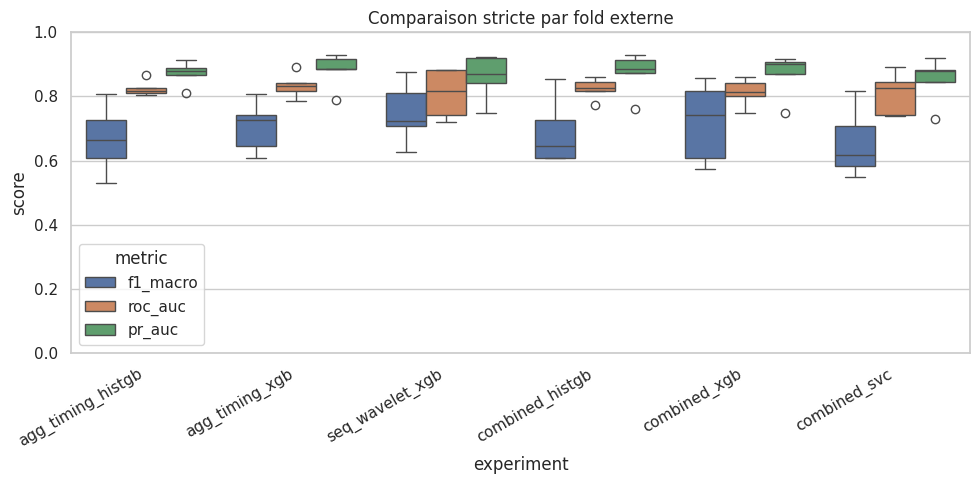

In [6]:
for experiment, data in oof_df.groupby("experiment"):
    print("\n" + "=" * 80)
    print(experiment)
    print(classification_report(data.label, data.pred, target_names=["Contrôle", "Parkinson"]))
    cm = confusion_matrix(data.label, data.pred)
    display(pd.DataFrame(cm, index=["Réel contrôle", "Réel Parkinson"], columns=["Prédit contrôle", "Prédit Parkinson"]))

plt.figure(figsize=(10, 5))
plot_df = results_df.melt(
    id_vars=["experiment", "outer_fold"],
    value_vars=["f1_macro", "roc_auc", "pr_auc"],
    var_name="metric",
    value_name="score",
)
sns.boxplot(data=plot_df, x="experiment", y="score", hue="metric")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.title("Comparaison stricte par fold externe")
plt.tight_layout()
plt.show()


## 6. Analyse des résultats

Le notebook 08 montre une amélioration nette par rapport aux expériences strictes précédentes. La meilleure variante en F1 macro est `seq_wavelet_xgb`, qui utilise uniquement les features fréquentielles/ondelettes avec XGBoost. Elle obtient `0.749 ± 0.096` en F1 macro, `0.760 ± 0.090` en balanced accuracy, et `0.809 ± 0.076` en ROC-AUC.

La meilleure variante en ROC-AUC est différente : `agg_timing_xgb` obtient `0.834 ± 0.039` en ROC-AUC et `0.882 ± 0.055` en PR-AUC, avec `0.706 ± 0.080` en F1 macro. Cela veut dire que les features agrégées avec XGBoost classent très bien les sujets en score de risque, même si le seuil choisi ne donne pas le meilleur F1.

Comparaison principale :

| Variante | F1 macro | ROC-AUC | PR-AUC | Balanced accuracy |
|---|---:|---:|---:|---:|
| `seq_wavelet_xgb` | `0.749 ± 0.096` | `0.809 ± 0.076` | `0.861 ± 0.071` | `0.760 ± 0.090` |
| `combined_xgb` | `0.720 ± 0.125` | `0.814 ± 0.043` | `0.869 ± 0.070` | `0.729 ± 0.122` |
| `agg_timing_xgb` | `0.706 ± 0.080` | `0.834 ± 0.039` | `0.882 ± 0.055` | `0.715 ± 0.074` |
| `combined_histgb` | `0.688 ± 0.106` | `0.825 ± 0.033` | `0.872 ± 0.066` | `0.697 ± 0.101` |
| `agg_timing_histgb` | `0.668 ± 0.107` | `0.826 ± 0.024` | `0.873 ± 0.039` | `0.681 ± 0.098` |
| `combined_svc` | `0.655 ± 0.108` | `0.809 ± 0.068` | `0.851 ± 0.073` | `0.667 ± 0.100` |

Interprétation :

- Les features ondelettes/fréquentielles améliorent nettement la décision binaire quand elles sont utilisées seules avec XGBoost.
- Les features agrégées classiques restent très fortes pour produire un score de risque, comme le montre leur ROC-AUC élevée.
- Combiner toutes les features ne donne pas forcément le meilleur résultat : `combined_xgb` est bon, mais inférieur à `seq_wavelet_xgb` en F1 et inférieur à `agg_timing_xgb` en AUC. Cela suggère que l’ajout massif de features peut introduire du bruit.
- XGBoost améliore clairement les variantes agrégées par rapport à HistGB en F1 macro (`0.706` contre `0.668`).

Par rapport au notebook 07, la meilleure variante passe d’environ `0.672` à `0.749` en F1 macro. C’est cohérent avec l’intuition de l’état de l’art : les représentations temporelles/fréquentielles capturent des irrégularités que les simples moyennes, écarts-types et quantiles ne voient pas.

La prochaine étape raisonnable n’est pas d’exporter directement ce modèle. Il faut plutôt intégrer ces candidats dans une validation imbriquée stricte de type notebook 06, en sélectionnant entre `agg_timing_xgb`, `seq_wavelet_xgb`, `combined_xgb` et éventuellement une version PSO ou sélection de features.
